In [1]:
print ('h')

h


In [10]:
import os
print(os.path.expanduser("~"))

/Users/migaelmeyer


In [11]:
import pandas as pd

df = pd.read_csv("/Users/migaelmeyer/Downloads/mental-heath-in-tech-2016_20161114.csv")
print(df)

      Are you self-employed?  \
0                          0   
1                          0   
2                          0   
3                          1   
4                          0   
...                      ...   
1428                       1   
1429                       1   
1430                       0   
1431                       0   
1432                       0   

     How many employees does your company or organization have?  \
0                                                26-100           
1                                                  6-25           
2                                                  6-25           
3                                                   NaN           
4                                                  6-25           
...                                                 ...           
1428                                                NaN           
1429                                                NaN           
1430        

In [12]:
print(df.isnull().sum())

Are you self-employed?                                                                  0
How many employees does your company or organization have?                            287
Is your employer primarily a tech company/organization?                               287
Is your primary role within your company related to tech/IT?                         1170
Does your employer provide mental health benefits as part of healthcare coverage?     287
                                                                                     ... 
What US state or territory do you live in?                                            593
What country do you work in?                                                            0
What US state or territory do you work in?                                            582
Which of the following best describes your work position?                               0
Do you work remotely?                                                                   0
Length: 63

In [13]:
print(df.shape)  # (rows, columns) = (respondents, variables)


(1433, 63)


In [14]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct)

If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?            89.951151
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?    85.764131
Is your primary role within your company related to tech/IT?                                                                            81.646895
Do you know local or online resources to seek help for a mental health disorder?                                                        79.972087
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?                   79.972087
                                                                                                                                          ...    
Do you feel that being identified as a person with a mental health issue would hurt your career?                            

In [15]:
n_rows, n_cols = df.shape
max_missing_col = missing_pct.idxmax()
max_missing_val = missing_pct.max()

print(f"The dataset contains {n_rows} respondents and {n_cols} variables. "
      f"'{max_missing_col}' has the most missingness at {max_missing_val:.1f}%.")

The dataset contains 1433 respondents and 63 variables. 'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?' has the most missingness at 90.0%.


In [17]:
import pandas as pd

raw_df = pd.read_csv(
    "/Users/migaelmeyer/Downloads/mental-heath-in-tech-2016_20161114.csv"
)

print(f"Respondents: {raw_df.shape[0]}")
print(f"Variables: {raw_df.shape[1]}")

missing = pd.DataFrame({
    "Missing count": raw_df.isna().sum(),
    "Missing (%)": (raw_df.isna().mean() * 100).round(1)
})

print("\n10 questions with the most missing values:")
print(
    missing.sort_values("Missing count", ascending=False)
    .head(10)
    .to_string()
)

Respondents: 1433
Variables: 63

10 questions with the most missing values:
                                                                                                                                      Missing count  Missing (%)
If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?                   1289         90.0
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?           1229         85.8
Is your primary role within your company related to tech/IT?                                                                                   1170         81.6
Do you know local or online resources to seek help for a mental health disorder?                                                               1146         80.0
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?  

In [18]:
# Reproduce the initial encoding approach
baseline_df = raw_df.replace({"Yes": 1, "No": 0})
baseline_df = pd.get_dummies(baseline_df)

print(f"Variables before encoding: {raw_df.shape[1]}")
print(f"Features after encoding: {baseline_df.shape[1]}")
print(f"Missing values before zero-fill: {baseline_df.isna().sum().sum()}")

baseline_df = baseline_df.fillna(0)

print(f"Missing values after zero-fill: {baseline_df.isna().sum().sum()}")
print(f"Respondents retained: {baseline_df.shape[0]}")

Variables before encoding: 63
Features after encoding: 3216
Missing values before zero-fill: 2603
Missing values after zero-fill: 0
Respondents retained: 1433


In [19]:
selected_features = [
    "Are you self-employed?",
    "Is your employer primarily a tech company/organization?",
    "Is your primary role within your company related to tech/IT?",
    "Do you have previous employers?",
    "Have you ever sought treatment for a mental health issue from a mental health professional?",
    "What is your age?"
]

refined_raw = raw_df[selected_features].copy()

feature_summary = pd.DataFrame({
    "Data type": refined_raw.dtypes.astype(str),
    "Missing count": refined_raw.isna().sum(),
    "Missing (%)": (refined_raw.isna().mean() * 100).round(1)
})

print(feature_summary.to_string())

print("\nObserved values in the five binary features:")
for column in selected_features[:-1]:
    print(f"\n{column}")
    print(refined_raw[column].value_counts(dropna=False).to_string())

print("\nAge summary:")
print(refined_raw["What is your age?"].describe().to_string())

                                                                                            Data type  Missing count  Missing (%)
Are you self-employed?                                                                          int64              0          0.0
Is your employer primarily a tech company/organization?                                       float64            287         20.0
Is your primary role within your company related to tech/IT?                                  float64           1170         81.6
Do you have previous employers?                                                                 int64              0          0.0
Have you ever sought treatment for a mental health issue from a mental health professional?     int64              0          0.0
What is your age?                                                                               int64              0          0.0

Observed values in the five binary features:

Are you self-employed?
Are you self-employe

In [20]:
# Check whether missing answers follow employment circumstances
print("Tech-company responses by self-employment:")
print(pd.crosstab(
    refined_raw["Are you self-employed?"],
    refined_raw[
        "Is your employer primarily a tech company/organization?"
    ].fillna("Missing")
).to_string())

print("\nTech-role responses by employer classification:")
print(pd.crosstab(
    refined_raw[
        "Is your employer primarily a tech company/organization?"
    ].fillna("Missing"),
    refined_raw[
        "Is your primary role within your company related to tech/IT?"
    ].fillna("Missing")
).to_string())

# Flag unusual ages for inspection without changing them
age = refined_raw["What is your age?"]

print("\nMinimum age:", age.min())
print("Maximum age:", age.max())
print("\nAges outside 18–100, with counts:")
print(age[~age.between(18, 100)].value_counts().sort_index().to_string())

Tech-company responses by self-employment:
Is your employer primarily a tech company/organization?  0.0  1.0  Missing
Are you self-employed?                                                    
0                                                        263  883        0
1                                                          0    0      287

Tech-role responses by employer classification:
Is your primary role within your company related to tech/IT?  0.0  1.0  Missing
Is your employer primarily a tech company/organization?                        
0.0                                                            15  248        0
1.0                                                             0    0      883
Missing                                                         0    0      287

Minimum age: 3
Maximum age: 323

Ages outside 18–100, with counts:
What is your age?
3      1
15     1
17     1
323    1


In [21]:
print("Median values for the six selected features:")
print(refined_raw.median().to_string())

Median values for the six selected features:
Are you self-employed?                                                                          0.0
Is your employer primarily a tech company/organization?                                         1.0
Is your primary role within your company related to tech/IT?                                    1.0
Do you have previous employers?                                                                 1.0
Have you ever sought treatment for a mental health issue from a mental health professional?     1.0
What is your age?                                                                              33.0


In [24]:
%pip install scikit-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/60/ea/57e57539ce175d774fc291ed091b0a6d756854b92cd92554c6bb4d0ae498/scikit_learn-1.9.1-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/a5/f6/a5b82f8abbe14d134691b8b903696f701d25a081353a29dc655c364d9e62/scipy-1.18.1-cp312-cp312-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 275.8 kB/s eta 0:00:00a 0:00:01
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/40/b5/1b84b2c784db76d69442334bc8b8748c840f13ca53be086f4f250ad4a0bc/narwhals-2.26.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolc

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproduce the report's median-imputed analysis
imputer = SimpleImputer(strategy="median")

refined_imputed = pd.DataFrame(
    imputer.fit_transform(refined_raw),
    columns=refined_raw.columns,
    index=refined_raw.index
)

scaler = StandardScaler()
refined_scaled = scaler.fit_transform(refined_imputed)

kmeans = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)
refined_labels = kmeans.fit_predict(refined_scaled)

print("Cluster sizes:")
print(
    pd.Series(refined_labels)
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .to_string()
)

pca = PCA(n_components=2, svd_solver="full")
refined_pca = pca.fit_transform(refined_scaled)

print("\nPCA explained variance:")
for i, variance in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {variance:.2%}")

print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

print("\nCluster profiles — original units, after imputation:")
profiles = refined_imputed.assign(cluster=refined_labels)
print(profiles.groupby("cluster").mean().T.round(4).to_string())

Cluster sizes:
Cluster
0     264
1    1169

PCA explained variance:
PC1: 22.64%
PC2: 19.40%
Total: 42.04%

Cluster profiles — original units, after imputation:
cluster                                                                                            0        1
Are you self-employed?                                                                        0.0000   0.2455
Is your employer primarily a tech company/organization?                                       0.0038   1.0000
Is your primary role within your company related to tech/IT?                                  0.9432   1.0000
Do you have previous employers?                                                               0.8636   0.8862
Have you ever sought treatment for a mental health issue from a mental health professional?   0.5720   0.5885
What is your age?                                                                            36.4508  33.7973


In [26]:
from sklearn.metrics import silhouette_score

evaluation = []

for k in range(1, 10):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(refined_scaled)

    score = (
        silhouette_score(refined_scaled, labels)
        if k >= 2 else float("nan")
    )

    evaluation.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": score
    })

refined_evaluation = pd.DataFrame(evaluation)

print(refined_evaluation.round(4).to_string(index=False))

best = refined_evaluation.dropna(subset=["Silhouette"])
best = best.loc[best["Silhouette"].idxmax()]

print(f"\nHighest silhouette score: {best['Silhouette']:.4f}")
print(f"Number of clusters at that score: {int(best['k'])}")

 k   Inertia  Silhouette
 1 8598.0000         NaN
 2 7010.2758      0.3922
 3 5643.5973      0.3710
 4 4253.3192      0.4399
 5 3182.9949      0.4948
 6 2397.5494      0.5555
 7 1751.3618      0.5612
 8 1515.0416      0.5926
 9 1300.6148      0.6206

Highest silhouette score: 0.6206
Number of clusters at that score: 9


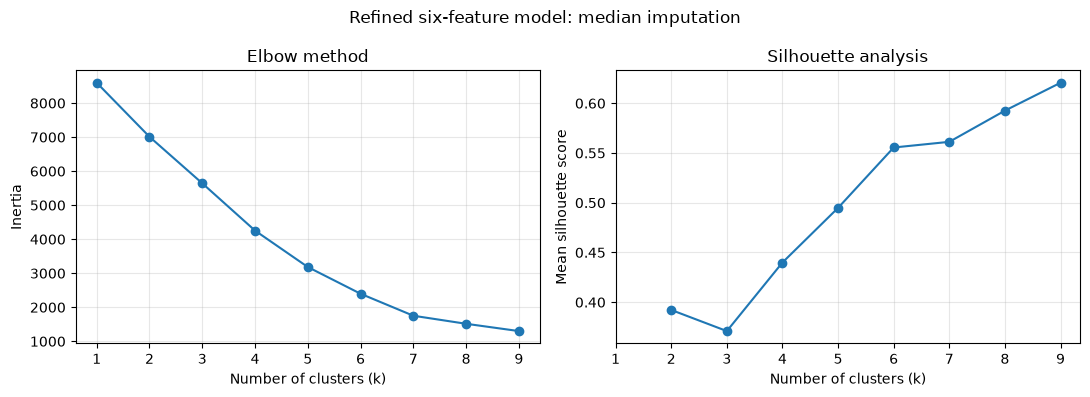

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    refined_evaluation["k"],
    refined_evaluation["Inertia"],
    marker="o"
)
axes[0].set(
    title="Elbow method",
    xlabel="Number of clusters (k)",
    ylabel="Inertia"
)

valid_scores = refined_evaluation.dropna(subset=["Silhouette"])

axes[1].plot(
    valid_scores["k"],
    valid_scores["Silhouette"],
    marker="o"
)
axes[1].set(
    title="Silhouette analysis",
    xlabel="Number of clusters (k)",
    ylabel="Mean silhouette score"
)

for ax in axes:
    ax.set_xticks(range(1, 10))
    ax.grid(alpha=0.3)

fig.suptitle("Refined six-feature model: median imputation")
plt.tight_layout()

plt.savefig(
    "refined_elbow_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [28]:
age_column = "What is your age?"

for k in [2, 9]:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(refined_scaled)

    check = pd.DataFrame({
        "Cluster": labels,
        "Age": refined_raw[age_column].to_numpy()
    })

    print(f"\nCLUSTER SUMMARY FOR k={k}")
    print(
        check.groupby("Cluster").agg(
            Respondents=("Age", "size"),
            Minimum_age=("Age", "min"),
            Median_age=("Age", "median"),
            Maximum_age=("Age", "max")
        ).to_string()
    )

    print("\nRespondents with ages outside 18–100:")
    print(
        check.loc[~check["Age"].between(18, 100)]
        .to_string(index=False)
    )


CLUSTER SUMMARY FOR k=2
         Respondents  Minimum_age  Median_age  Maximum_age
Cluster                                                   
0                264           19        34.0          323
1               1169            3        32.0           99

Respondents with ages outside 18–100:
 Cluster  Age
       1   17
       0  323
       1    3
       1   15

CLUSTER SUMMARY FOR k=9
         Respondents  Minimum_age  Median_age  Maximum_age
Cluster                                                   
0                465            3        32.0           99
1                 88           19        35.0           59
2                322           17        32.0           58
3                 88           21        35.0           54
4                161           19        36.0           65
5                 15           22        32.0           74
6                127           21        34.0           66
7                166           15        28.0           62
8              

In [29]:
# Separate sensitivity analysis: correct two implausible ages
age_checked = refined_raw.copy()
age_column = "What is your age?"

age_checked.loc[
    age_checked[age_column].isin([3, 323]),
    age_column
] = float("nan")

age_checked_imputed = SimpleImputer(
    strategy="median"
).fit_transform(age_checked)

age_checked_scaled = StandardScaler().fit_transform(
    age_checked_imputed
)

age_results = []

for k in range(1, 10):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(age_checked_scaled)

    age_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": (
            silhouette_score(age_checked_scaled, labels)
            if k >= 2 else float("nan")
        )
    })

age_evaluation = pd.DataFrame(age_results)

comparison = refined_evaluation[["k", "Silhouette"]].merge(
    age_evaluation[["k", "Silhouette"]],
    on="k",
    suffixes=("_original", "_age_corrected")
)

print(comparison.round(4).to_string(index=False))

 k  Silhouette_original  Silhouette_age_corrected
 1                  NaN                       NaN
 2               0.3922                    0.3624
 3               0.3710                    0.3785
 4               0.4399                    0.4069
 5               0.4948                    0.4542
 6               0.5555                    0.4940
 7               0.5612                    0.4851
 8               0.5926                    0.5108
 9               0.6206                    0.5388


In [30]:
# Use the age-corrected data from the previous step
comparison_features = [
    "Are you self-employed?",
    "Do you have previous employers?",
    "Have you ever sought treatment for a mental health issue from a mental health professional?",
    "What is your age?"
]

four_feature_raw = age_checked[comparison_features].copy()

four_feature_imputed = SimpleImputer(
    strategy="median"
).fit_transform(four_feature_raw)

four_feature_scaled = StandardScaler().fit_transform(
    four_feature_imputed
)

four_feature_results = []

for k in range(1, 10):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(four_feature_scaled)

    four_feature_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": (
            silhouette_score(four_feature_scaled, labels)
            if k >= 2 else float("nan")
        )
    })

four_feature_evaluation = pd.DataFrame(four_feature_results)

print(four_feature_evaluation.round(4).to_string(index=False))

 k   Inertia  Silhouette
 1 5732.0000         NaN
 2 4256.1008      0.4035
 3 2998.5620      0.4255
 4 1957.5344      0.5248
 5 1592.9112      0.5261
 6 1355.7094      0.5540
 7 1164.3628      0.5661
 8  991.7692      0.5552
 9  837.5100      0.5717


In [31]:
for k in [4, 7, 9]:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(four_feature_scaled)

    profiles = pd.DataFrame(
        four_feature_imputed,
        columns=["Self-employed", "Previous employers", "Treatment", "Age"]
    )
    profiles["Cluster"] = labels

    grouped = profiles.groupby("Cluster")
    summary = grouped.mean()

    # Express binary means as percentages
    binary_columns = ["Self-employed", "Previous employers", "Treatment"]
    summary[binary_columns] *= 100

    summary.insert(0, "Respondents", grouped.size())
    summary = summary.rename(columns={
        "Self-employed": "Self-employed (%)",
        "Previous employers": "Previous employers (%)",
        "Treatment": "Treatment (%)",
        "Age": "Mean age"
    })

    print(f"\nCLUSTER PROFILES: k={k}")
    print(summary.round(1).to_string())


CLUSTER PROFILES: k=4
         Respondents  Self-employed (%)  Previous employers (%)  Treatment (%)  Mean age
Cluster                                                                                 
0                598                0.0                   100.0          100.0      34.2
1                417                0.0                   100.0            0.0      33.4
2                169               22.5                     0.0           47.3      30.8
3                249              100.0                   100.0           64.7      37.3

CLUSTER PROFILES: k=7
         Respondents  Self-employed (%)  Previous employers (%)  Treatment (%)  Mean age
Cluster                                                                                 
0                433                0.0                   100.0          100.0      30.3
1                408                0.0                   100.0            0.0      32.9
2                161              100.0                   100.0 

In [32]:
# The previous cell left "summary" containing the k=9 profiles.
# Print each cluster separately to avoid a truncated table.

for cluster, row in summary.iterrows():
    print(
        f"Cluster {cluster}: "
        f"n={int(row['Respondents'])}, "
        f"self-employed={row['Self-employed (%)']:.1f}%, "
        f"previous employers={row['Previous employers (%)']:.1f}%, "
        f"treatment={row['Treatment (%)']:.1f}%, "
        f"mean age={row['Mean age']:.1f}"
    )

Cluster 0: n=55, self-employed=98.2%, previous employers=100.0%, treatment=94.5%, mean age=50.8
Cluster 1: n=433, self-employed=0.0%, previous employers=100.0%, treatment=100.0%, mean age=30.3
Cluster 2: n=130, self-employed=0.0%, previous employers=0.0%, treatment=44.6%, mean age=29.7
Cluster 3: n=275, self-employed=0.0%, previous employers=100.0%, treatment=0.0%, mean age=29.4
Cluster 4: n=165, self-employed=0.0%, previous employers=99.4%, treatment=100.0%, mean age=44.3
Cluster 5: n=38, self-employed=100.0%, previous employers=0.0%, treatment=55.3%, mean age=33.7
Cluster 6: n=110, self-employed=100.0%, previous employers=100.0%, treatment=100.0%, mean age=32.6
Cluster 7: n=85, self-employed=100.0%, previous employers=100.0%, treatment=0.0%, mean age=35.3
Cluster 8: n=142, self-employed=0.0%, previous employers=100.0%, treatment=0.0%, mean age=41.0


In [33]:

from sklearn.cluster import AgglomerativeClustering

method_comparison = []

for k in [4, 7, 9]:
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    hierarchical_labels = hierarchical.fit_predict(
        four_feature_scaled
    )

    hierarchical_score = silhouette_score(
        four_feature_scaled,
        hierarchical_labels
    )

    kmeans_score = four_feature_evaluation.loc[
        four_feature_evaluation["k"] == k,
        "Silhouette"
    ].iloc[0]

    sizes = pd.Series(hierarchical_labels).value_counts()

    method_comparison.append({
        "k": k,
        "K-Means silhouette": kmeans_score,
        "Hierarchical silhouette": hierarchical_score,
        "Smallest hierarchical cluster": sizes.min(),
        "Largest hierarchical cluster": sizes.max()
    })

method_comparison = pd.DataFrame(method_comparison)

print(method_comparison.round(4).to_string(index=False))

 k  K-Means silhouette  Hierarchical silhouette  Smallest hierarchical cluster  Largest hierarchical cluster
 4              0.5248                   0.5248                            169                           598
 7              0.5661                   0.5650                             38                           489
 9              0.5717                   0.5593                             38                           489


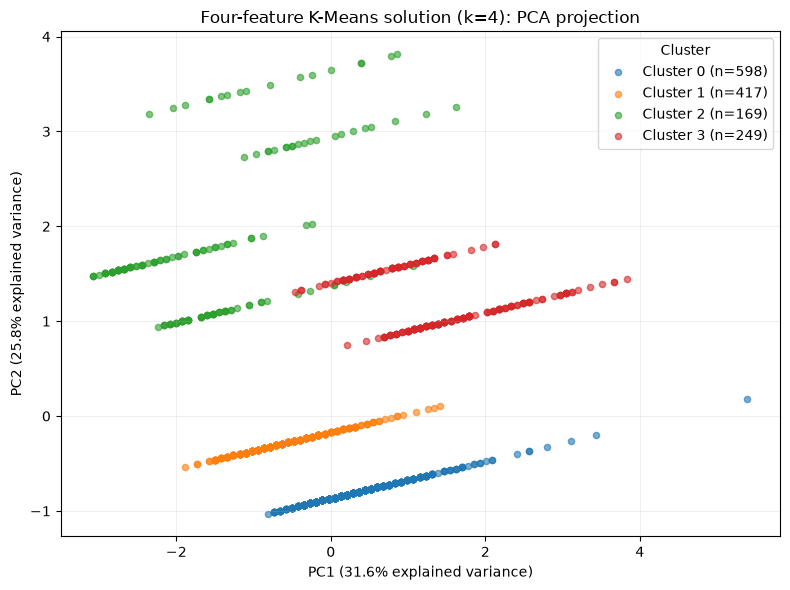

PC1: 31.55%
PC2: 25.76%
Total variance shown: 57.32%


In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Final exploratory model: four features, corrected ages
final_model = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)
final_labels = final_model.fit_predict(four_feature_scaled)

# PCA is used only for visualisation
final_pca = PCA(n_components=2, svd_solver="full")
final_coordinates = final_pca.fit_transform(four_feature_scaled)

variance = final_pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))

for cluster in sorted(set(final_labels)):
    mask = final_labels == cluster

    ax.scatter(
        final_coordinates[mask, 0],
        final_coordinates[mask, 1],
        s=20,
        alpha=0.6,
        label=f"Cluster {cluster} (n={mask.sum()})"
    )

ax.set(
    title="Four-feature K-Means solution (k=4): PCA projection",
    xlabel=f"PC1 ({variance[0]:.1%} explained variance)",
    ylabel=f"PC2 ({variance[1]:.1%} explained variance)"
)
ax.legend(title="Cluster")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("final_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"PC1: {variance[0]:.2%}")
print(f"PC2: {variance[1]:.2%}")
print(f"Total variance shown: {variance.sum():.2%}")

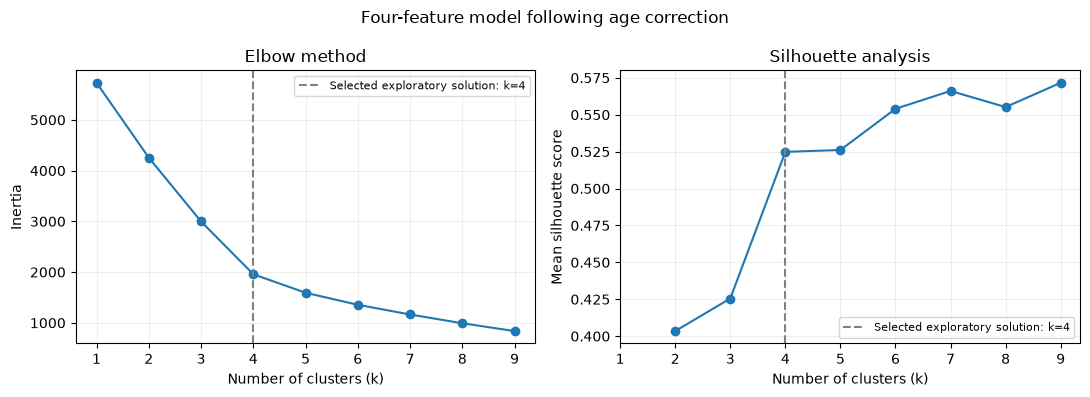

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    four_feature_evaluation["k"],
    four_feature_evaluation["Inertia"],
    marker="o"
)
axes[0].set(
    title="Elbow method",
    xlabel="Number of clusters (k)",
    ylabel="Inertia"
)

scores = four_feature_evaluation.dropna(subset=["Silhouette"])

axes[1].plot(
    scores["k"],
    scores["Silhouette"],
    marker="o"
)
axes[1].set(
    title="Silhouette analysis",
    xlabel="Number of clusters (k)",
    ylabel="Mean silhouette score"
)

for ax in axes:
    ax.axvline(
        4, color="grey", linestyle="--",
        label="Selected exploratory solution: k=4"
    )
    ax.set_xticks(range(1, 10))
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle("Four-feature model following age correction")
plt.tight_layout()
plt.savefig(
    "final_elbow_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()